In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

In [2]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split

ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))

one_hot_encoder = OneHotEncoder(sparse=False)
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
grps_xoh = df[genes].nunique().values

Xnum = df_chs.loc[:, df_chs.nunique(dropna=False) > 1].values
grps_xnum = np.sum( (df_chs.nunique(dropna=False) > 1).values.reshape(-1, 4) , axis=-1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

def cv_splitter(X, y, strat, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, strat):
        yield X[train_idxs], X[test_idxs], y[train_idxs], y[test_idxs], strat[train_idxs], strat[test_idxs]

def group_sum(arr, grp_sizes):
    assert arr.shape[-1] == np.sum(grp_sizes)
    result = []
    lb = 0
    for grp_size in grp_sizes:
        result.append( np.sum(arr[..., lb:lb+grp_size], axis=-1) )
        lb += grp_size
    result = np.stack(result, axis=-1)
    return result

def ungroup(arr, grp_sizes):
    result = []
    cumsum = np.insert(np.cumsum(grp_sizes), 0, 0)
    for i in arr:
        result.append(np.arange(cumsum[i], cumsum[i+1]))
    return np.concatenate(result)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

n_splits = 5
work_log_ = dict()

## Distance-irrelevant classifiers: CategoricalNB, Categorical RF, Catboost

In [30]:
from sklearn.naive_bayes import CategoricalNB

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xcat, y, y, n_splits=n_splits, random_state=42)):
    min_categories = np.max(Xcat, axis=0).astype(int)+1
    model = CategoricalNB(
        alpha=1.,
        min_categories=np.max(Xcat, axis=0).astype(int)+1
        )
    model.fit(X_train, y_train)
    work_log_[f'CatNB_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'CatNB_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

In [ ]:
# from sklearn_genetic import GASearchCV
# from sklearn_genetic import space

# param_grid = {
#     'criterion': space.Categorical(['gini', 'entropy'], random_state=42) , 
#     'max_depth': space.Integer(2, 10, random_state=42),
#     'min_samples_split': space.Integer(2, 20, random_state=42),
#     'min_samples_leaf': space.Integer(2, 20, random_state=42), 
# }

# ga_cv = GASearchCV(
#     DecisionTreeClassifier(
#         random_state=42
#     ),
#     cv=5,
#     param_grid=param_grid,
# )
# ga_cv.fit(Xoh, y)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 568,
    'criterion': 'entropy',
    'max_depth': 14,
    'min_samples_split': 0.003294411356704213,
    'min_samples_leaf': 0.0010234416524205442,
}

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xoh, y, y, n_splits=n_splits, random_state=42)):
    model = RandomForestClassifier(
        **rf_params,
        random_state=42
    )
    model.fit(X_train, y_train)
    work_log_[f'RF_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'RF_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

In [14]:
from catboost import CatBoostClassifier, EFstrType, Pool

catboost_params = {
    'iterations': 1690,
    'learning_rate': 0.07455163375490914,
    'depth': 5,
    'l2_leaf_reg': 0.2593960559993001
}

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(df[genes].values.astype('<U2'), y, y, n_splits=n_splits, random_state=42)):
    model = CatBoostClassifier(random_state=42)
    model.fit(
        Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
        verbose=0
    )
    work_log_[f'CatBoost_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'CatBoost_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

## LR, SVM, KNN, MultinomialNB

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import distance_metrics

def nan_l1_dist(X, Y, missing_values=np.nan):
    diff = X - Y
    na_count = np.sum(np.isnan(diff))
    distance = np.nansum(np.abs(diff))
    distance *= (X.shape[-1] / (X.shape[-1]-na_count))
    return distance  

In [17]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xnum, y, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        LogisticRegression(
            penalty='l2',
            C=1., 
            solver='saga', 
            max_iter=1000,
            random_state=42
        )
    )
    model.set_params(**lr_params)
    model.fit(X_train, y_train)
    work_log_[f'LR_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'LR_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

In [18]:
from sklearn.svm import SVC

svc_params = {
    'knnimputer__n_neighbors': 12,
    'knnimputer__metric': 'nan_euclidean',
    'svc__C': 0.3289812567312727,
    'svc__kernel': 'poly',
    'svc__degree': 8,
    'svc__gamma': 'auto'
}
for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xnum, y, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        SVC(
            C=1., 
            kernel='rbf',
            degree=3,
            gamma='scale',
            coef0=0.0,
            random_state=42
        )
    )
    model.set_params(**svc_params)
    model.fit(X_train, y_train)
    work_log_[f'SVM_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'SVM_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn_params= {
    'knnimputer__n_neighbors': 6,
    'knnimputer__metric': 'nan_euclidean',
    'kneighborsclassifier__n_neighbors': 15,
    'kneighborsclassifier__weights': 'distance',
    'kneighborsclassifier__metric': 'euclidean'
}
for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xnum, y, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        KNeighborsClassifier(
            n_neighbors=25, 
            weights='uniform',
            metric='manhattan'
        )
    )
    model.set_params(**knn_params)
    model.fit(X_train, y_train)
    work_log_[f'KNN_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'KNN_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

In [20]:
from sklearn.naive_bayes import MultinomialNB

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xnum, y, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MultinomialNB(
            alpha=1.
        )
    )
    model.fit(X_train, y_train)
    work_log_[f'MultNB_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'MultNB_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

## What about DNN?

In [21]:
from sklearn.neural_network import MLPClassifier

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(Xnum, y, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MLPClassifier(
            hidden_layer_sizes=(128, 32, ),
            alpha=1e-2,
            max_iter=2000,
        )
    )
    model.fit(X_train, y_train)
    work_log_[f'FFN_train_{i}'] = accuracy_score(y_train, model.predict(X_train))
    work_log_[f'FFN_test_{i}' ] = accuracy_score(y_test,  model.predict(X_test ))

## Figures

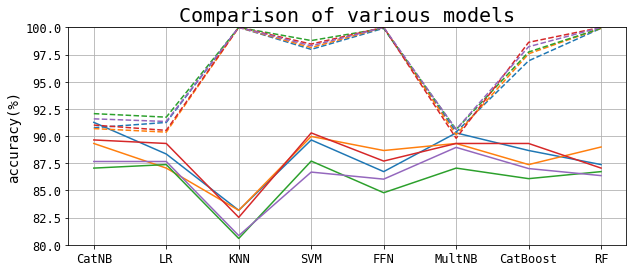

In [27]:
plt.figure(figsize=(10, 4))

model_names = list(set(key.split('_')[0] for key in work_log_.keys()))
for i in range(5):
    for tt in ['train', 'test']:
        arr = [100*work_log_[f'{model_name}_{tt}_{i}'] for model_name in model_names]
        plt.plot(
            model_names, arr, 
            linestyle='-' if tt=='test' else '--',
            color=f'C{i}')

plt.title('Comparison of various models', fontsize=20)
plt.xticks(fontsize=12)
plt.ylim(80, 100); plt.yticks(fontsize=12); plt.ylabel('accuracy(%)', fontsize=14)
plt.grid(); plt.show(); plt.close()

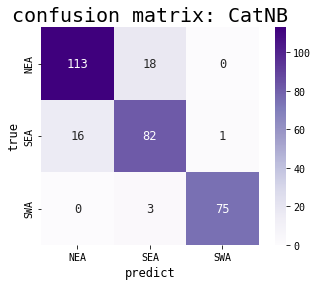

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)), fmt='d',
    cmap='Purples', annot=True, annot_kws={'fontsize': 12}, square=True,
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_
)
plt.title('confusion matrix: CatNB', fontsize=20)
plt.xlabel('predict', fontsize=12)
plt.ylabel('true', fontsize=12)
plt.show(); plt.close()

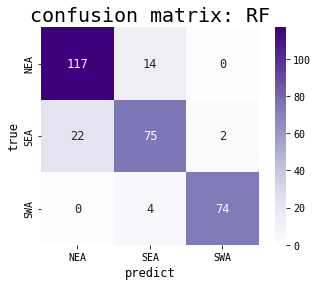

In [45]:
sns.heatmap(
    confusion_matrix(y_test, model.predict(X_test)), fmt='d',
    cmap='Purples', annot=True, annot_kws={'fontsize': 12}, square=True,
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_
)
plt.title('confusion matrix: RF', fontsize=20)
plt.xlabel('predict', fontsize=12)
plt.ylabel('true', fontsize=12)
plt.show(); plt.close()